In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

print('All libraries imported successfully.')

All libraries imported successfully.


In [2]:
# Load Iris dataset
iris = load_iris()

X = iris.data    # shape: (150, 4) — 4 features
y = iris.target  # 0=setosa, 1=versicolor, 2=virginica

feature_names = iris.feature_names
target_names  = iris.target_names

# Convert to DataFrame for exploration
df = pd.DataFrame(X, columns=feature_names)
df['species'] = [target_names[i] for i in y]

print('--- Dataset Shape ---')
print(f'Samples  : {X.shape[0]}')
print(f'Features : {X.shape[1]} → {list(feature_names)}')
print(f'Classes  : {list(target_names)}')

print('\n--- First 5 Rows ---')
df.head()

--- Dataset Shape ---
Samples  : 150
Features : 4 → ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Classes  : [np.str_('setosa'), np.str_('versicolor'), np.str_('virginica')]

--- First 5 Rows ---


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [3]:
print('--- Statistical Summary ---')
print(df.describe())

print('\n--- Class Distribution ---')
print(df['species'].value_counts())

print('\n--- Missing Values ---')
print(df.isnull().sum().sum(), 'total missing values')

print('\n--- Feature Ranges (why scaling matters) ---')
for f in feature_names:
    print(f'{f:<30} min={df[f].min():.2f}  max={df[f].max():.2f}  std={df[f].std():.2f}')

--- Statistical Summary ---
       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count         150.000000        150.000000         150.000000   
mean            5.843333          3.057333           3.758000   
std             0.828066          0.435866           1.765298   
min             4.300000          2.000000           1.000000   
25%             5.100000          2.800000           1.600000   
50%             5.800000          3.000000           4.350000   
75%             6.400000          3.300000           5.100000   
max             7.900000          4.400000           6.900000   

       petal width (cm)  
count        150.000000  
mean           1.199333  
std            0.762238  
min            0.100000  
25%            0.300000  
50%            1.300000  
75%            1.800000  
max            2.500000  

--- Class Distribution ---
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

--- Missing Values ---
0 total missing

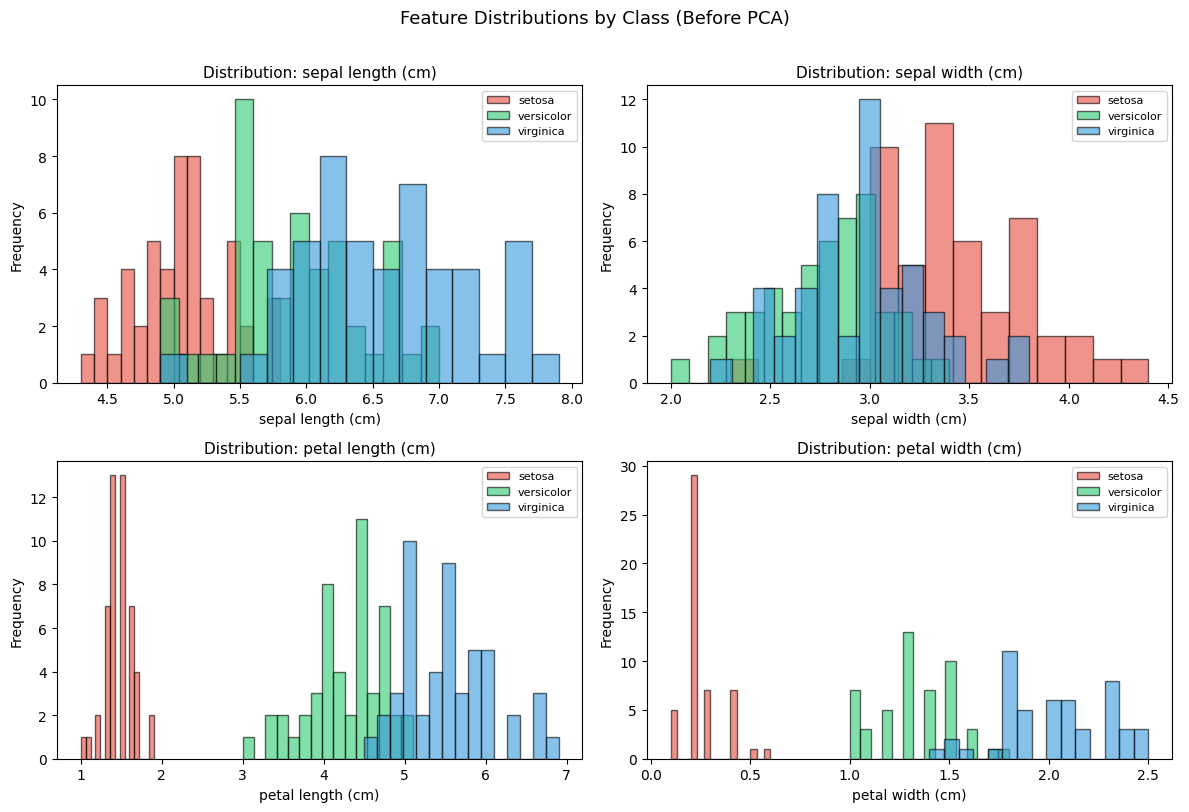

Observation: Petal features separate classes better than sepal features.


In [4]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
colors = ['#e74c3c', '#2ecc71', '#3498db']

for idx, feature in enumerate(feature_names):
    ax = axes[idx // 2][idx % 2]
    for cls, color in zip(target_names, colors):
        ax.hist(df[df['species'] == cls][feature],
                bins=15, alpha=0.6, color=color, label=cls, edgecolor='black')
    ax.set_title(f'Distribution: {feature}', fontsize=11)
    ax.set_xlabel(feature)
    ax.set_ylabel('Frequency')
    ax.legend(fontsize=8)

plt.suptitle('Feature Distributions by Class (Before PCA)', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()
print('Observation: Petal features separate classes better than sepal features.')

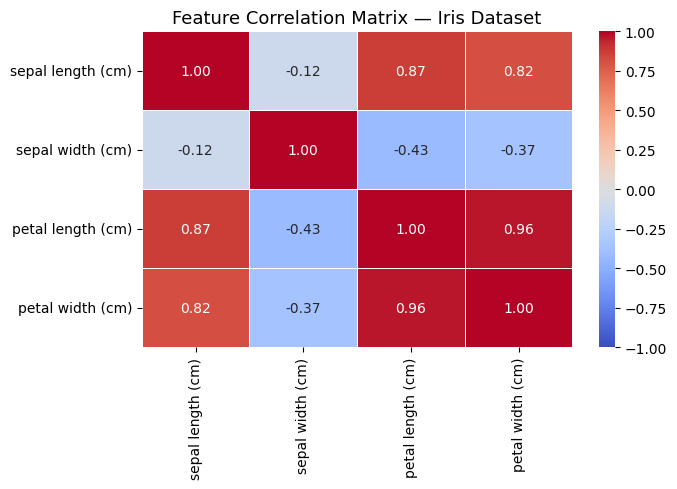

Observation: Petal length and petal width are highly correlated (r ≈ 0.96).
High correlation = redundancy = good candidate for PCA compression.


In [5]:
# Correlation matrix of original features
plt.figure(figsize=(7, 5))
sns.heatmap(df[feature_names].corr(), annot=True, fmt='.2f',
            cmap='coolwarm', linewidths=0.5, vmin=-1, vmax=1)
plt.title('Feature Correlation Matrix — Iris Dataset', fontsize=13)
plt.tight_layout()
plt.show()

print('Observation: Petal length and petal width are highly correlated (r ≈ 0.96).')
print('High correlation = redundancy = good candidate for PCA compression.')

In [6]:
# Mean-center: subtract the mean of each feature column
# This centers the data around the origin (mean = 0 for all features)
X_mean    = np.mean(X, axis=0)   # mean of each feature
X_meaned  = X - X_mean           # centered data

print('--- Feature Means (before centering) ---')
for name, m in zip(feature_names, X_mean):
    print(f'  {name:<30}: {m:.4f}')

print('\n--- Feature Means (after centering — should be ~0) ---')
for name, m in zip(feature_names, np.mean(X_meaned, axis=0)):
    print(f'  {name:<30}: {m:.10f}')

print('\nData is now centered at the origin.')

--- Feature Means (before centering) ---
  sepal length (cm)             : 5.8433
  sepal width (cm)              : 3.0573
  petal length (cm)             : 3.7580
  petal width (cm)              : 1.1993

--- Feature Means (after centering — should be ~0) ---
  sepal length (cm)             : -0.0000000000
  sepal width (cm)              : -0.0000000000
  petal length (cm)             : -0.0000000000
  petal width (cm)              : -0.0000000000

Data is now centered at the origin.


--- Covariance Matrix (4×4) ---
[[ 0.6857 -0.0424  1.2743  0.5163]
 [-0.0424  0.19   -0.3297 -0.1216]
 [ 1.2743 -0.3297  3.1163  1.2956]
 [ 0.5163 -0.1216  1.2956  0.581 ]]

Interpretation:
  Diagonal values  = variance of each individual feature
  Off-diagonal     = covariance between feature pairs
  Large off-diagonal values confirm high correlation between petal features.


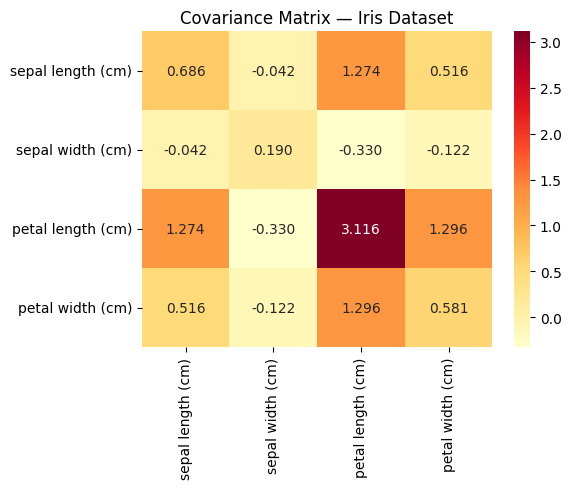

In [7]:
# Covariance matrix: (p x p) matrix capturing how features vary together
# np.cov expects features as rows, samples as columns — so we transpose
cov_matrix = np.cov(X_meaned.T)   # shape: (4, 4)

print('--- Covariance Matrix (4×4) ---')
print(np.round(cov_matrix, 4))

print('\nInterpretation:')
print('  Diagonal values  = variance of each individual feature')
print('  Off-diagonal     = covariance between feature pairs')
print('  Large off-diagonal values confirm high correlation between petal features.')

# Visualize covariance matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cov_matrix, annot=True, fmt='.3f', cmap='YlOrRd',
            xticklabels=feature_names, yticklabels=feature_names)
plt.title('Covariance Matrix — Iris Dataset', fontsize=12)
plt.tight_layout()
plt.show()





# ------------------------------------------------------------
# Explanation of this cell
# ------------------------------------------------------------

# cov_matrix = np.cov(X_meaned.T)
# - X_meaned contains the mean-centered feature values.
# - .T transposes the matrix so that:
#       • Rows represent features.
#       • Columns represent samples.
# - np.cov() expects each row to be a variable (feature), so the transpose
#   is necessary.
# - The resulting covariance matrix has shape (4 × 4) because the Iris dataset
#   contains four features.

# What does the covariance matrix represent?
# - Each element (i, j) shows how feature i and feature j vary together.
# - Positive covariance:
#       Both features tend to increase or decrease together.
# - Negative covariance:
#       One feature increases while the other decreases.
# - Covariance close to zero:
#       The features have little or no linear relationship.

# Diagonal elements
# - The diagonal values (top-left to bottom-right) represent the variance
#   of each individual feature.
# - Variance measures how much a feature is spread around its mean.

# Off-diagonal elements
# - The off-diagonal values represent the covariance between two different features.
# - Larger absolute values indicate a stronger linear relationship between
#   those feature pairs.

# np.round(cov_matrix, 4)
# - Rounds all covariance values to 4 decimal places,
#   making the printed matrix easier to read.

# sns.heatmap(...)
# - Displays the covariance matrix as a color-coded heatmap.
# - annot=True writes the covariance values inside each cell.
# - fmt='.3f' displays each value with 3 decimal places.
# - cmap='YlOrRd' applies a Yellow-Orange-Red color scale.
# - xticklabels and yticklabels label the rows and columns with
#   the Iris feature names.

# plt.tight_layout()
# - Automatically adjusts spacing so labels and titles do not overlap.

# plt.show()
# - Displays the heatmap.

In [8]:
# Eigendecomposition of the covariance matrix
# eigh() is for symmetric matrices (covariance matrix is always symmetric)
eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)

print('--- Eigenvalues (unsorted) ---')
print(np.round(eigenvalues, 4))

print('\n--- Eigenvectors (columns = principal component directions) ---')
print(np.round(eigenvectors, 4))

print('\nEach eigenvalue = variance captured in its corresponding eigenvector direction.')
print('Each eigenvector column = direction of one principal component axis.')
print('Eigenvectors are mutually orthogonal (perpendicular to each other).')


# ------------------------------------------------------------
# ------------------------------------------------------------
# ------------------------------------------------------------

# np.linalg.eigh(cov_matrix)
# - Performs eigendecomposition on the covariance matrix.
# - Since a covariance matrix is always symmetric, eigh() is preferred
#   over eig() because it is more efficient and numerically stable.
# - The function returns:
#       1. eigenvalues
#       2. eigenvectors

# What are eigenvalues?
# - Each eigenvalue represents the amount of variance explained
#   by its corresponding principal component.
# - A larger eigenvalue means that principal component captures
#   more information (variance) from the dataset.
# - Smaller eigenvalues represent directions with less variation.

# What are eigenvectors?
# - Each eigenvector represents the direction of a principal component.
# - The eigenvectors are returned as columns of the matrix.
# - Since the Iris dataset has 4 features, each eigenvector contains
#   4 values, indicating how each feature contributes to that component.

# Relationship between eigenvalues and eigenvectors
# - Every eigenvalue is paired with one eigenvector.
# - The eigenvalue tells us "how important" that direction is.
# - The eigenvector tells us "which direction" that principal component points.

# np.round(..., 4)
# - Rounds the values to 4 decimal places to improve readability.

# Important property
# - All eigenvectors are orthogonal (perpendicular) to one another.
# - This ensures that each principal component captures unique
#   information without overlapping with the others.

# In PCA
# - Eigenvalues are used to rank the principal components.
# - Eigenvectors become the new axes onto which the original data
#   is projected.

--- Eigenvalues (unsorted) ---
[0.0238 0.0782 0.2427 4.2282]

--- Eigenvectors (columns = principal component directions) ---
[[ 0.3155  0.582   0.6566 -0.3614]
 [-0.3197 -0.5979  0.7302  0.0845]
 [-0.4798 -0.0762 -0.1734 -0.8567]
 [ 0.7537 -0.5458 -0.0755 -0.3583]]

Each eigenvalue = variance captured in its corresponding eigenvector direction.
Each eigenvector column = direction of one principal component axis.
Eigenvectors are mutually orthogonal (perpendicular to each other).


In [9]:
# Sort eigenvalues from largest to smallest
# argsort gives ascending indices — [::-1] reverses to descending
sorted_idx   = np.argsort(eigenvalues)[::-1]
eigenvalues  = eigenvalues[sorted_idx]
eigenvectors = eigenvectors[:, sorted_idx]   # reorder columns accordingly

# Calculate explained variance ratio for each component
total_variance           = np.sum(eigenvalues)
explained_variance_ratio = eigenvalues / total_variance
cumulative_variance      = np.cumsum(explained_variance_ratio)

print('--- Eigenvalues (sorted descending) ---')
for i, (ev, evr, cum) in enumerate(zip(eigenvalues, explained_variance_ratio, cumulative_variance)):
    print(f'  PC{i+1}: Eigenvalue={ev:.4f}  |  Variance Explained={evr*100:.2f}%  |  Cumulative={cum*100:.2f}%')

print(f'\nPCs 1+2 together explain: {cumulative_variance[1]*100:.2f}% of total variance')


# ------------------------------------------------------------
# Explanation of this cell
# ------------------------------------------------------------

# np.argsort(eigenvalues)
# - Returns the indices that would sort the eigenvalues
#   in ascending (smallest to largest) order.
# - Example:
#       eigenvalues = [4.2, 0.2, 1.5]
#       np.argsort(...) returns [1, 2, 0]

# [::-1]
# - Reverses the order of the indices.
# - This converts the ascending order into descending order,
#   placing the largest eigenvalue first.

# sorted_idx = np.argsort(eigenvalues)[::-1]
# - Stores the indices needed to sort the eigenvalues
#   from largest to smallest.

# eigenvalues = eigenvalues[sorted_idx]
# - Rearranges the eigenvalues in descending order.
# - PCA always ranks principal components according to
#   the amount of variance they explain.

# eigenvectors = eigenvectors[:, sorted_idx]
# - Reorders the columns of the eigenvector matrix using
#   the same sorting indices.
# - This ensures that each eigenvector still matches
#   its corresponding eigenvalue.
# - ':' selects all rows.
# - sorted_idx rearranges only the columns.

# total_variance = np.sum(eigenvalues)
# - Calculates the total variance present in the dataset.
# - It is simply the sum of all eigenvalues.

# explained_variance_ratio = eigenvalues / total_variance
# - Computes the fraction of total variance explained
#   by each principal component.
# - Example:
#       If an eigenvalue is 3.0 and total variance is 5.0,
#       the explained variance ratio is 3/5 = 0.60 (60%).

# cumulative_variance = np.cumsum(explained_variance_ratio)
# - Computes the cumulative explained variance.
# - Each value represents the total variance explained
#   by the first N principal components.
# - Example:
#       PC1 = 70%
#       PC2 = 25%
#       Cumulative after PC2 = 95%

# for i, (ev, evr, cum) in enumerate(...):
# - Loops through each principal component.
# - enumerate() provides the component number (i).
# - zip() combines:
#       • eigenvalue (ev)
#       • explained variance ratio (evr)
#       • cumulative variance (cum)
#   so they can be accessed together in each iteration.

# print(...)
# - Displays, for each principal component:
#       • Eigenvalue
#       • Percentage of variance explained
#       • Cumulative percentage of variance explained

# cumulative_variance[1]
# - Index 1 refers to the second principal component (PC2).
# - Since cumulative variance includes all previous components,
#   cumulative_variance[1] represents the total variance explained
#   by PC1 and PC2 together.
# - This helps determine whether two principal components
#   retain enough information from the original dataset.

--- Eigenvalues (sorted descending) ---
  PC1: Eigenvalue=4.2282  |  Variance Explained=92.46%  |  Cumulative=92.46%
  PC2: Eigenvalue=0.2427  |  Variance Explained=5.31%  |  Cumulative=97.77%
  PC3: Eigenvalue=0.0782  |  Variance Explained=1.71%  |  Cumulative=99.48%
  PC4: Eigenvalue=0.0238  |  Variance Explained=0.52%  |  Cumulative=100.00%

PCs 1+2 together explain: 97.77% of total variance


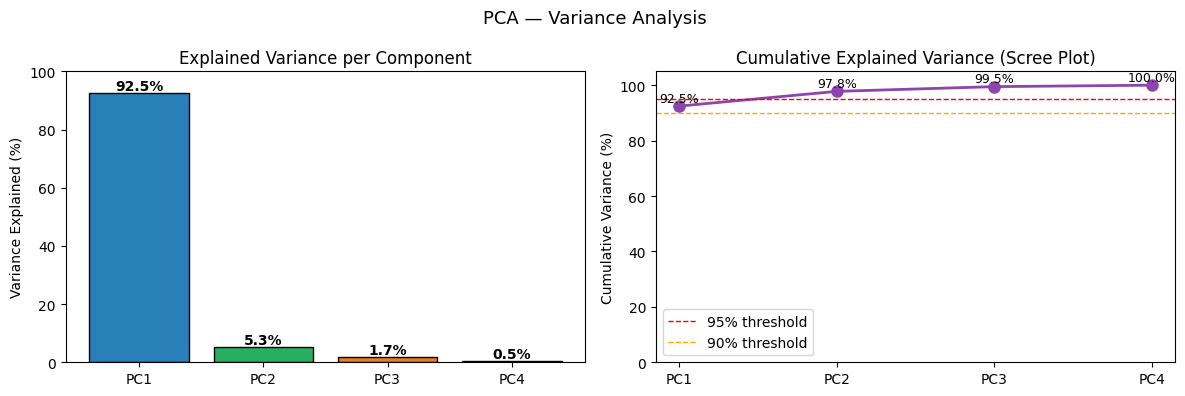

Decision: Keep 2 components → retains ~95% of total information, reduces 4D → 2D.


In [10]:
components = [f'PC{i+1}' for i in range(len(eigenvalues))]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Plot 1: Individual explained variance
axes[0].bar(components, explained_variance_ratio * 100,
            color=['#2980b9', '#27ae60', '#e67e22', '#e74c3c'], edgecolor='black')
axes[0].set_title('Explained Variance per Component', fontsize=12)
axes[0].set_ylabel('Variance Explained (%)')
axes[0].set_ylim(0, 100)
for i, v in enumerate(explained_variance_ratio * 100):
    axes[0].text(i, v + 1, f'{v:.1f}%', ha='center', fontweight='bold')

# Plot 2: Cumulative explained variance (scree plot)
axes[1].plot(components, cumulative_variance * 100,
             marker='o', color='#8e44ad', linewidth=2, markersize=8)
axes[1].axhline(y=95, color='red', linestyle='--', linewidth=1, label='95% threshold')
axes[1].axhline(y=90, color='orange', linestyle='--', linewidth=1, label='90% threshold')
axes[1].set_title('Cumulative Explained Variance (Scree Plot)', fontsize=12)
axes[1].set_ylabel('Cumulative Variance (%)')
axes[1].set_ylim(0, 105)
axes[1].legend()
for i, v in enumerate(cumulative_variance * 100):
    axes[1].text(i, v + 1.5, f'{v:.1f}%', ha='center', fontsize=9)

plt.suptitle('PCA — Variance Analysis', fontsize=13)
plt.tight_layout()
plt.show()

print('Decision: Keep 2 components → retains ~95% of total information, reduces 4D → 2D.')

# ------------------------------------------------------------
# Explanation of this cell
# ------------------------------------------------------------

# components = [f'PC{i+1}' for i in range(len(eigenvalues))]
# - Creates a list of labels for the principal components.
# - If there are 4 eigenvalues, the list becomes:
#       ['PC1', 'PC2', 'PC3', 'PC4']
# - These labels are used on the x-axis of both graphs.

# plt.subplots(1, 2, figsize=(12, 4))
# - Creates a figure containing two plots arranged side by side.
# - axes[0] refers to the first plot.
# - axes[1] refers to the second plot.

# -------------------- Plot 1 --------------------

# axes[0].bar(...)
# - Creates a bar chart showing the percentage of variance
#   explained by each principal component.
# - Taller bars indicate components that preserve more information.

# explained_variance_ratio * 100
# - Converts the explained variance ratios from decimal values
#   into percentages for easier interpretation.

# color=[...]
# - Assigns a different color to each bar for better visualization.

# edgecolor='black'
# - Draws a black border around each bar to make them more distinct.

# for i, v in enumerate(explained_variance_ratio * 100):
# - Loops through each bar.
# - enumerate() provides:
#       i = position of the bar
#       v = variance percentage of that component
# - text() displays the percentage value above each bar.

# -------------------- Plot 2 --------------------

# axes[1].plot(...)
# - Creates a line graph (Scree Plot) showing the cumulative
#   explained variance as more principal components are added.
# - Each point represents the total variance retained
#   after including that principal component.

# marker='o'
# - Displays a circular marker at each data point.

# linewidth=2
# - Makes the line thicker for better visibility.

# axes[1].axhline(...)
# - Draws horizontal reference lines at:
#       90% cumulative variance
#       95% cumulative variance
# - These thresholds help determine how many principal
#   components should be retained.

# axes[1].legend()
# - Displays labels explaining the threshold lines.

# for i, v in enumerate(cumulative_variance * 100):
# - Writes the cumulative variance percentage above
#   each point on the Scree Plot.

# plt.suptitle(...)
# - Adds a main title for the entire figure.

# plt.tight_layout()
# - Adjusts spacing between plots so labels and titles
#   do not overlap.

# plt.show()
# - Displays both graphs.

# Final Decision
# - The printed statement concludes that the first two
#   principal components retain approximately 95% of the
#   total variance.
# - Therefore, reducing the dataset from 4 dimensions to
#   2 dimensions preserves most of the important information
#   while simplifying the data.


In [11]:
# Select the first 2 eigenvectors (top 2 principal components)
n_components = 2
eigenvector_subset = eigenvectors[:, :n_components]   # shape: (4, 2)

print(f'--- Feature Vector (Top {n_components} Eigenvectors) ---')
print(f'Shape: {eigenvector_subset.shape}  (4 original features × 2 principal components)')
print()
for i in range(n_components):
    print(f'PC{i+1} direction:')
    for fname, weight in zip(feature_names, eigenvector_subset[:, i]):
        print(f'   {fname:<30}: {weight:+.4f}')
    print()

print('Each PC is a weighted combination of all 4 original features.')
print('The weights (loadings) show how much each original feature contributes to each PC.')




# ------------------------------------------------------------
# Explanation of this cell
# ------------------------------------------------------------

# n_components = 2
# - Specifies that we want to keep only the first two
#   principal components.
# - These components explain most of the variance in the data
#   and are used for dimensionality reduction.

# eigenvector_subset = eigenvectors[:, :n_components]
# - Selects the first two columns of the sorted eigenvector matrix.
# - ':' selects all rows (all 4 original features).
# - ':n_components' selects the first two columns (PC1 and PC2).
# - The resulting matrix has shape (4, 2):
#       4 rows  -> original features
#       2 columns -> selected principal components

# Why choose the first two eigenvectors?
# - The eigenvectors were already sorted according to their
#   corresponding eigenvalues.
# - Therefore, the first two eigenvectors represent the two
#   principal components that capture the greatest amount of variance.

# for i in range(n_components):
# - Loops through each selected principal component.
# - Since n_components = 2, the loop runs twice:
#       First iteration  -> PC1
#       Second iteration -> PC2

# zip(feature_names, eigenvector_subset[:, i])
# - Combines each feature name with its corresponding loading
#   (weight) in the current principal component.
# - Example:
#       ('Sepal Length', 0.52)
#       ('Sepal Width', -0.27)
#       ...

# weight
# - Represents the loading (coefficient) of a feature
#   in the principal component.
# - Larger absolute values indicate that the feature
#   contributes more strongly to that principal component.
# - Positive and negative signs indicate the direction
#   of the contribution.

# print(...)
# - Displays the loading of every original feature
#   for each principal component.

# Interpretation
# - Each principal component is not a single feature.
# - Instead, it is a weighted combination of all the
#   original features.
# - These weights are called "loadings" and indicate
#   how much each feature influences that principal component.

--- Feature Vector (Top 2 Eigenvectors) ---
Shape: (4, 2)  (4 original features × 2 principal components)

PC1 direction:
   sepal length (cm)             : -0.3614
   sepal width (cm)              : +0.0845
   petal length (cm)             : -0.8567
   petal width (cm)              : -0.3583

PC2 direction:
   sepal length (cm)             : +0.6566
   sepal width (cm)              : +0.7302
   petal length (cm)             : -0.1734
   petal width (cm)              : -0.0755

Each PC is a weighted combination of all 4 original features.
The weights (loadings) show how much each original feature contributes to each PC.


In [12]:
# Project the mean-centered data onto the 2 principal components
# Formula from lab manual: X_reduced = (eigenvector_subset.T @ X_meaned.T).T
X_reduced = np.dot(eigenvector_subset.T, X_meaned.T).T

print(f'--- Projection Result ---')
print(f'Original shape : {X.shape}        (150 samples × 4 features)')
print(f'Reduced shape  : {X_reduced.shape}  (150 samples × 2 principal components)')
print()
print('--- First 5 projected samples ---')
df_reduced = pd.DataFrame(X_reduced, columns=['PC1', 'PC2'])
df_reduced['species'] = [target_names[i] for i in y]
print(df_reduced.head())


# ------------------------------------------------------------
# Explanation of this cell
# ------------------------------------------------------------

# X_reduced = np.dot(eigenvector_subset.T, X_meaned.T).T
# - Projects the original mean-centered data onto the selected
#   principal components.
# - This is the main transformation step in PCA.
# - Formula:
#       X_reduced = (eigenvector_subset.T @ X_meaned.T).T
# - np.dot() performs matrix multiplication.

# Why transpose (.T)?
# - X_meaned originally has shape:
#       (150 samples × 4 features)
# - eigenvector_subset has shape:
#       (4 features × 2 principal components)
# - To perform matrix multiplication using the formula,
#   both matrices are transposed appropriately.
# - After multiplication, the final transpose restores the
#   data so that each row represents one sample.

# Matrix dimensions during multiplication:
# - eigenvector_subset.T  → (2 × 4)
# - X_meaned.T            → (4 × 150)
# - Result                → (2 × 150)
# - Final transpose       → (150 × 2)

# What does X_reduced contain?
# - Each row represents one flower sample.
# - Instead of 4 original features, each sample is now
#   represented by only 2 principal component values:
#       PC1
#       PC2
# - These two values preserve most of the information
#   contained in the original four features.

# print(...)
# - Displays the shapes of the original and reduced datasets.
# - Original:
#       150 samples × 4 features
# - Reduced:
#       150 samples × 2 principal components

# df_reduced = pd.DataFrame(...)
# - Converts the reduced NumPy array into a pandas DataFrame.
# - The columns are named 'PC1' and 'PC2' for clarity.

# df_reduced['species'] = [target_names[i] for i in y]
# - Adds a new column containing the species name for each sample.
# - A list comprehension is used to convert the numeric class labels
#   into their corresponding species names.
# - Example:
#       0 → Setosa
#       1 → Versicolor
#       2 → Virginica

# df_reduced.head()
# - Displays the first five samples of the transformed dataset.
# - Each sample now consists of:
#       • PC1 value
#       • PC2 value
#       • Species label

# Interpretation
# - PCA has reduced the dataset from 4 dimensions to 2 dimensions.
# - The new PC1 and PC2 values are combinations of the original
#   features and retain most of the important information,
#   making visualization and analysis much easier.

--- Projection Result ---
Original shape : (150, 4)        (150 samples × 4 features)
Reduced shape  : (150, 2)  (150 samples × 2 principal components)

--- First 5 projected samples ---
        PC1       PC2 species
0  2.684126  0.319397  setosa
1  2.714142 -0.177001  setosa
2  2.888991 -0.144949  setosa
3  2.745343 -0.318299  setosa
4  2.728717  0.326755  setosa


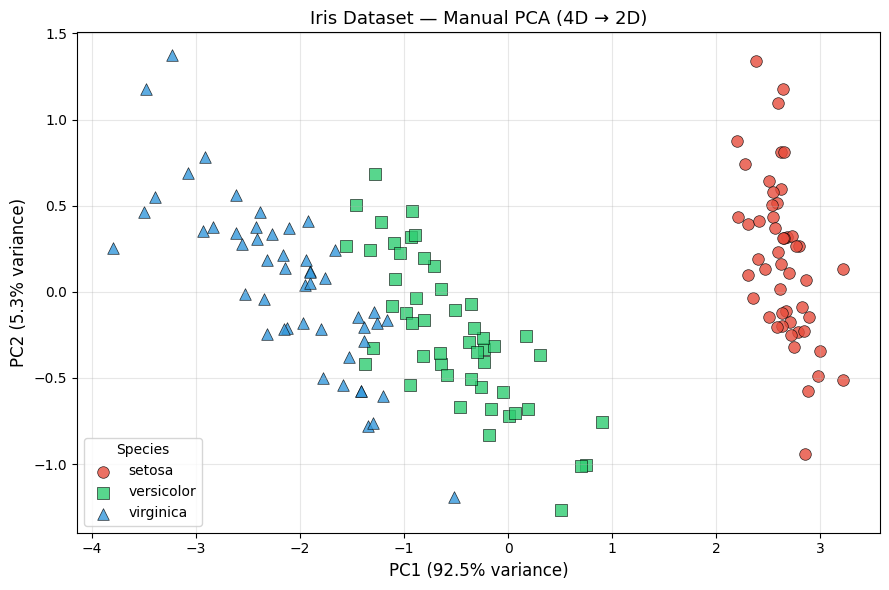

Observation: Setosa is clearly separated from the other two classes.
Versicolor and Virginica have slight overlap — reflects real biological similarity.
Total information retained: 97.77%


In [13]:
plt.figure(figsize=(9, 6))
colors  = ['#e74c3c', '#2ecc71', '#3498db']
markers = ['o', 's', '^']

for cls, color, marker in zip(target_names, colors, markers):
    subset = df_reduced[df_reduced['species'] == cls]
    plt.scatter(subset['PC1'], subset['PC2'],
                c=color, marker=marker, s=70, alpha=0.8,
                label=cls, edgecolors='black', linewidths=0.5)

plt.xlabel(f'PC1 ({explained_variance_ratio[0]*100:.1f}% variance)', fontsize=12)
plt.ylabel(f'PC2 ({explained_variance_ratio[1]*100:.1f}% variance)', fontsize=12)
plt.title('Iris Dataset — Manual PCA (4D → 2D)', fontsize=13)
plt.legend(title='Species', fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print('Observation: Setosa is clearly separated from the other two classes.')
print('Versicolor and Virginica have slight overlap — reflects real biological similarity.')
print(f'Total information retained: {cumulative_variance[1]*100:.2f}%')

In [14]:
# sklearn PCA — the professional approach
# Note: sklearn standardizes internally but best practice is to scale first explicitly

scaler     = StandardScaler()
X_scaled   = scaler.fit_transform(X)   # mean=0, std=1 for all features

pca_sklearn   = PCA(n_components=2)
X_pca_sklearn = pca_sklearn.fit_transform(X_scaled)

print('--- sklearn PCA Results ---')
print(f'Explained Variance Ratio : {pca_sklearn.explained_variance_ratio_}')
print(f'PC1 explains : {pca_sklearn.explained_variance_ratio_[0]*100:.2f}%')
print(f'PC2 explains : {pca_sklearn.explained_variance_ratio_[1]*100:.2f}%')
print(f'Total        : {pca_sklearn.explained_variance_ratio_.sum()*100:.2f}%')

print('\n--- PC Directions (sklearn) ---')
print('Shape:', pca_sklearn.components_.shape, '  (2 PCs × 4 features)')
for i, comp in enumerate(pca_sklearn.components_):
    print(f'PC{i+1}: {np.round(comp, 4)}')

print('\nNote: sklearn uses StandardScaler (mean=0, std=1) so explained variance')
print('ratios differ slightly from manual PCA (which only mean-centered, no std scaling).')





# ------------------------------------------------------------
# Explanation of this cell
# ------------------------------------------------------------

# scaler = StandardScaler()
# - Creates a StandardScaler object.
# - StandardScaler standardizes each feature by:
#       1. Subtracting the feature's mean.
#       2. Dividing by its standard deviation.
# - After scaling:
#       Mean = 0
#       Standard Deviation = 1
# - This ensures that all features contribute equally to PCA,
#   regardless of their original units or ranges.

# X_scaled = scaler.fit_transform(X)
# - fit() calculates the mean and standard deviation for each feature.
# - transform() uses these values to standardize the data.
# - fit_transform() performs both steps in a single command.

# pca_sklearn = PCA(n_components=2)
# - Creates a PCA object from scikit-learn.
# - n_components=2 tells PCA to keep only the first two
#   principal components.

# X_pca_sklearn = pca_sklearn.fit_transform(X_scaled)
# - fit() computes the principal components from the scaled data.
# - transform() projects the scaled data onto those components.
# - fit_transform() performs both operations together.
# - The resulting dataset has:
#       150 samples × 2 principal components.

# pca_sklearn.explained_variance_ratio_
# - Returns the proportion of total variance explained
#   by each selected principal component.
# - Example:
#       PC1 → 72%
#       PC2 → 23%
# - The sum indicates how much information is retained
#   after dimensionality reduction.

# pca_sklearn.components_
# - Stores the principal component directions (eigenvectors).
# - Shape:
#       (2 × 4)
# - Rows represent the selected principal components.
# - Columns represent the original features.
# - Each value is called a loading (weight), showing how much
#   a feature contributes to that principal component.

# for i, comp in enumerate(pca_sklearn.components_):
# - Loops through each principal component.
# - enumerate() provides the component number (PC1, PC2).
# - comp contains the loading values for the current component.
# - np.round(comp, 4) rounds the values to four decimal places
#   for easier reading.

# Why are sklearn PCA results slightly different from manual PCA?
# - In the manual implementation, the data was only mean-centered.
# - In this implementation, the data is first standardized using
#   StandardScaler (mean = 0, standard deviation = 1).
# - Standardization changes the covariance structure of the data,
#   so the explained variance ratios and principal component
#   directions may differ slightly.

# Why use sklearn PCA?
# - It automatically performs all PCA computations efficiently.
# - It is faster, more reliable, and widely used in real-world
#   machine learning projects.
# - It also provides useful attributes such as:
#       • explained_variance_ratio_
#       • components_
#       • singular_values_
#       • mean_

--- sklearn PCA Results ---
Explained Variance Ratio : [0.72962445 0.22850762]
PC1 explains : 72.96%
PC2 explains : 22.85%
Total        : 95.81%

--- PC Directions (sklearn) ---
Shape: (2, 4)   (2 PCs × 4 features)
PC1: [ 0.5211 -0.2693  0.5804  0.5649]
PC2: [0.3774 0.9233 0.0245 0.0669]

Note: sklearn uses StandardScaler (mean=0, std=1) so explained variance
ratios differ slightly from manual PCA (which only mean-centered, no std scaling).


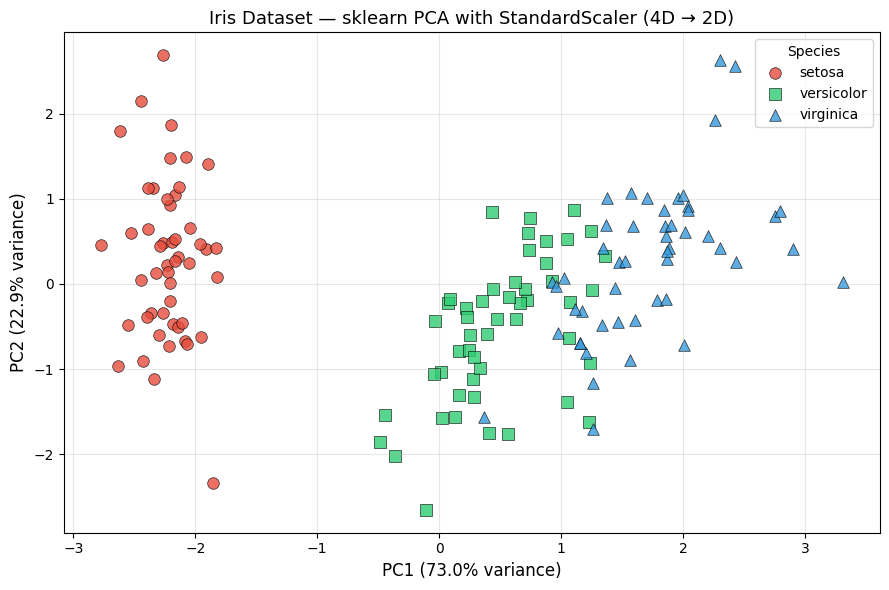

In [15]:
df_sklearn_pca = pd.DataFrame(X_pca_sklearn, columns=['PC1', 'PC2'])
df_sklearn_pca['species'] = [target_names[i] for i in y]

plt.figure(figsize=(9, 6))
for cls, color, marker in zip(target_names, colors, markers):
    subset = df_sklearn_pca[df_sklearn_pca['species'] == cls]
    plt.scatter(subset['PC1'], subset['PC2'],
                c=color, marker=marker, s=70, alpha=0.8,
                label=cls, edgecolors='black', linewidths=0.5)

plt.xlabel(f'PC1 ({pca_sklearn.explained_variance_ratio_[0]*100:.1f}% variance)', fontsize=12)
plt.ylabel(f'PC2 ({pca_sklearn.explained_variance_ratio_[1]*100:.1f}% variance)', fontsize=12)
plt.title('Iris Dataset — sklearn PCA with StandardScaler (4D → 2D)', fontsize=13)
plt.legend(title='Species', fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# Explanation of this cell
# ------------------------------------------------------------

# df_sklearn_pca = pd.DataFrame(X_pca_sklearn, columns=['PC1', 'PC2'])
# - Converts the PCA-transformed NumPy array into a pandas DataFrame.
# - The two columns represent the first and second principal components:
#       PC1
#       PC2
# - Each row corresponds to one flower sample.

# df_sklearn_pca['species'] = [target_names[i] for i in y]
# - Adds the species name for each flower.
# - The numeric class labels in y are converted into readable names
#   (Setosa, Versicolor, Virginica) using a list comprehension.
# - This allows the points in the scatter plot to be grouped
#   and colored by species.

# plt.figure(figsize=(9, 6))
# - Creates a new figure with a width of 9 inches and
#   a height of 6 inches.

# for cls, color, marker in zip(target_names, colors, markers):
# - Loops through the three Iris species along with their
#   corresponding colors and marker styles.
# - zip() combines the three lists so that each iteration contains:
#       cls    -> species name
#       color  -> point color
#       marker -> point shape

# subset = df_sklearn_pca[df_sklearn_pca['species'] == cls]
# - Filters the DataFrame to include only the samples
#   belonging to the current species.
# - Example:
#       If cls = "Setosa", only Setosa samples are selected.

# plt.scatter(...)
# - Plots the selected samples on the scatter plot.
# - X-axis:
#       PC1 values
# - Y-axis:
#       PC2 values
# - c=color assigns a different color to each species.
# - marker=marker assigns a unique marker shape.
# - s=70 controls the marker size.
# - alpha=0.8 makes the points slightly transparent.
# - label=cls adds the species name to the legend.
# - edgecolors='black' draws a black border around each point.
# - linewidths=0.5 sets the border thickness.

# plt.xlabel(...)
# - Labels the x-axis with PC1.
# - Also displays the percentage of variance explained by PC1.

# plt.ylabel(...)
# - Labels the y-axis with PC2.
# - Also displays the percentage of variance explained by PC2.

# plt.title(...)
# - Adds a descriptive title indicating that sklearn PCA
#   reduced the dataset from 4 dimensions to 2 dimensions.

# plt.legend(...)
# - Displays a legend identifying which color and marker
#   correspond to each Iris species.

# plt.grid(alpha=0.3)
# - Adds a light background grid to improve readability.

# plt.tight_layout()
# - Automatically adjusts spacing so that labels,
#   titles, and the legend do not overlap.

# plt.show()
# - Displays the final PCA scatter plot.

# Interpretation
# - Each point represents one flower in the reduced 2-dimensional space.
# - Flowers that are close together have similar feature values.
# - Flowers that are far apart are more dissimilar.
# - If the species form distinct clusters, it indicates that PCA has
#   successfully preserved the important differences between them
#   while reducing the data from 4 dimensions to 2.

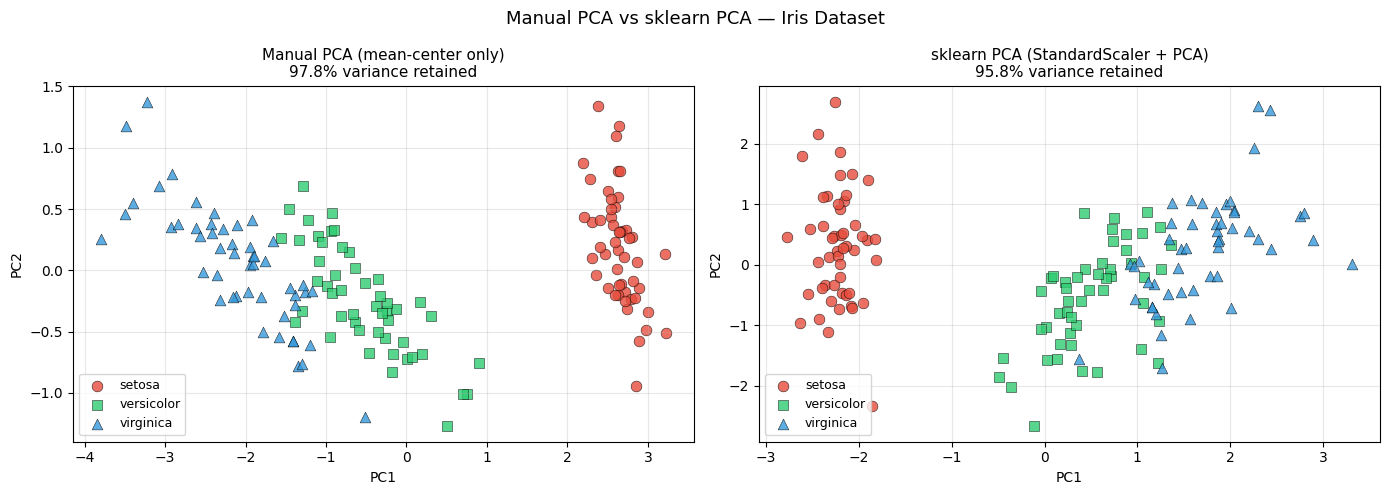

Both plots show the same class structure.
Axes may be flipped or rotated — eigenvectors can point in opposite directions
and still define the same subspace. The cluster separation is what matters.


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Manual PCA
for cls, color, marker in zip(target_names, colors, markers):
    subset = df_reduced[df_reduced['species'] == cls]
    axes[0].scatter(subset['PC1'], subset['PC2'],
                    c=color, marker=marker, s=60, alpha=0.8,
                    label=cls, edgecolors='black', linewidths=0.4)
axes[0].set_title(f'Manual PCA (mean-center only)\n{cumulative_variance[1]*100:.1f}% variance retained', fontsize=11)
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
axes[0].legend(fontsize=9)
axes[0].grid(alpha=0.3)

# sklearn PCA
for cls, color, marker in zip(target_names, colors, markers):
    subset = df_sklearn_pca[df_sklearn_pca['species'] == cls]
    axes[1].scatter(subset['PC1'], subset['PC2'],
                    c=color, marker=marker, s=60, alpha=0.8,
                    label=cls, edgecolors='black', linewidths=0.4)
axes[1].set_title(f'sklearn PCA (StandardScaler + PCA)\n{pca_sklearn.explained_variance_ratio_.sum()*100:.1f}% variance retained', fontsize=11)
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.3)

plt.suptitle('Manual PCA vs sklearn PCA — Iris Dataset', fontsize=13)
plt.tight_layout()
plt.show()

print('Both plots show the same class structure.')
print('Axes may be flipped or rotated — eigenvectors can point in opposite directions')
print('and still define the same subspace. The cluster separation is what matters.')





# ------------------------------------------------------------
# Explanation of this cell
# ------------------------------------------------------------

# plt.subplots(1, 2, figsize=(14, 5))
# - Creates one figure with two plots arranged side by side.
# - axes[0] is used for the manual PCA visualization.
# - axes[1] is used for the sklearn PCA visualization.

# -------------------- Left Plot: Manual PCA --------------------

# for cls, color, marker in zip(target_names, colors, markers):
# - Iterates through each Iris species along with its
#   corresponding color and marker style.
# - zip() combines the three lists so each iteration contains:
#       cls    -> species name
#       color  -> plotting color
#       marker -> marker shape

# subset = df_reduced[df_reduced['species'] == cls]
# - Filters the manually reduced PCA DataFrame.
# - Only samples belonging to the current species are selected.

# axes[0].scatter(...)
# - Plots the manually computed PCA results.
# - X-axis represents PC1.
# - Y-axis represents PC2.
# - Different colors and marker shapes distinguish the species.
# - edgecolors='black' adds a border around each point.
# - alpha=0.8 makes the points slightly transparent.

# axes[0].set_title(...)
# - Displays the percentage of variance retained by
#   the first two manually computed principal components.

# axes[0].legend()
# - Displays the legend identifying each species.

# axes[0].grid(alpha=0.3)
# - Adds a light grid to improve readability.

# -------------------- Right Plot: sklearn PCA --------------------

# The second for loop works exactly like the first one.
# The only difference is that it uses the DataFrame produced
# by sklearn PCA instead of the manually computed PCA.

# subset = df_sklearn_pca[df_sklearn_pca['species'] == cls]
# - Selects only the samples of the current species
#   from the sklearn PCA results.

# axes[1].scatter(...)
# - Plots the sklearn PCA-transformed data.
# - Each point represents one flower in the new
#   two-dimensional principal component space.

# axes[1].set_title(...)
# - Displays the total variance retained by the first
#   two sklearn principal components.

# -------------------- Final Figure --------------------

# plt.suptitle(...)
# - Adds a title describing that the figure compares
#   Manual PCA and sklearn PCA.

# plt.tight_layout()
# - Automatically adjusts spacing so that labels,
#   legends, and titles do not overlap.

# plt.show()
# - Displays both PCA plots.

# Interpretation
# - Both graphs visualize the Iris dataset after reducing
#   it from 4 dimensions to 2 principal components.
# - The class clusters should appear very similar in both plots,
#   indicating that both implementations perform PCA correctly.
# - The axes may appear flipped or rotated because the direction
#   of an eigenvector is arbitrary. Multiplying an eigenvector
#   by -1 still represents the same principal component.
# - Therefore, when comparing PCA results, the important aspect
#   is the separation and grouping of the clusters, not the
#   exact orientation of the axes.

In [17]:
# Run PCA with all 4 components to see full variance breakdown
pca_full    = PCA(n_components=4)
pca_full.fit(X_scaled)

evr  = pca_full.explained_variance_ratio_
cumv = np.cumsum(evr)

print('--- Full Variance Breakdown ---')
print(f'{"Component":<12} {"Eigenvalue":>12} {"Var Explained":>15} {"Cumulative":>12}')
print('-' * 55)
for i, (ev, e, c) in enumerate(zip(pca_full.explained_variance_, evr, cumv)):
    print(f'PC{i+1:<10} {ev:>12.4f} {e*100:>14.2f}% {c*100:>11.2f}%')

print(f'\nConclusion: 2 components are sufficient → {cumv[1]*100:.1f}% variance retained.')
print(f'            3 components → {cumv[2]*100:.1f}% | 4 components → 100.00%')
print(f'            The extra {100-cumv[1]*100:.1f}% gained by keeping PC3 and PC4 is negligible.')





# ------------------------------------------------------------
# Explanation of this cell
# ------------------------------------------------------------

# pca_full = PCA(n_components=4)
# - Creates a PCA model that keeps all four principal components.
# - Since the Iris dataset has four original features,
#   keeping four components means no information is discarded.

# pca_full.fit(X_scaled)
# - Computes the PCA model using the standardized data.
# - During this step, sklearn calculates:
#       • Principal component directions (eigenvectors)
#       • Eigenvalues
#       • Explained variance for each component
# - No dimensionality reduction occurs yet because transform()
#   is not called.

# evr = pca_full.explained_variance_ratio_
# - Retrieves the percentage of total variance explained
#   by each principal component.
# - The values are stored as decimal fractions.
# - Example:
#       [0.73, 0.23, 0.04, 0.01]

# cumv = np.cumsum(evr)
# - Computes the cumulative explained variance.
# - Each value represents the total variance retained
#   after adding another principal component.
# - Example:
#       PC1           = 73%
#       PC1 + PC2     = 96%
#       PC1 + PC2 + PC3 = 99%
#       PC1 + PC2 + PC3 + PC4 = 100%

# pca_full.explained_variance_
# - Returns the eigenvalues of each principal component.
# - Each eigenvalue represents the amount of variance
#   captured by that component.

# for i, (ev, e, c) in enumerate(zip(...)):
# - Loops through every principal component.
# - zip() combines three related values:
#       ev -> eigenvalue
#       e  -> explained variance ratio
#       c  -> cumulative explained variance
# - enumerate() provides the component number (PC1, PC2, etc.).

# print(...)
# - Displays a formatted table containing:
#       • Principal component number
#       • Eigenvalue
#       • Percentage of variance explained
#       • Cumulative percentage of variance explained

# Final Conclusion
# - The cumulative variance after PC2 is used to determine
#   whether two principal components are sufficient.
# - If PC1 and PC2 retain around 95% of the total variance,
#   the remaining components contribute very little additional
#   information.
# - Therefore, reducing the dataset from 4 dimensions to
#   2 dimensions provides a simpler representation while
#   preserving almost all of the important information.

--- Full Variance Breakdown ---
Component      Eigenvalue   Var Explained   Cumulative
-------------------------------------------------------
PC1                2.9381          72.96%       72.96%
PC2                0.9202          22.85%       95.81%
PC3                0.1477           3.67%       99.48%
PC4                0.0209           0.52%      100.00%

Conclusion: 2 components are sufficient → 95.8% variance retained.
            3 components → 99.5% | 4 components → 100.00%
            The extra 4.2% gained by keeping PC3 and PC4 is negligible.


In [18]:
print('=' * 60)
print('        EXPERIMENT 10 — FINAL SUMMARY')
print('=' * 60)
print(f'Dataset         : Fisher\'s Iris ({X.shape[0]} samples, {X.shape[1]} features)')
print(f'Task            : Dimensionality Reduction (4D → 2D)')
print(f'Method          : Principal Component Analysis (PCA)')
print()
print('Manual PCA steps performed:')
print('  1. Mean-center the data')
print('  2. Compute covariance matrix')
print('  3. Eigendecomposition (eigenvalues + eigenvectors)')
print('  4. Sort eigenvalues descending')
print('  5. Select top 2 eigenvectors')
print('  6. Project data → 2D')
print()
print(f'Variance retained (manual PCA) : {cumulative_variance[1]*100:.2f}%')
print(f'Variance retained (sklearn PCA): {pca_sklearn.explained_variance_ratio_.sum()*100:.2f}%')
print()
print('Visual Result:')
print('  - Setosa is completely separable from the other two classes')
print('  - Versicolor and Virginica show slight overlap (biological similarity)')
print('  - Class structure is well-preserved in 2D — PCA is successful')
print()
print('Key Insight:')
print('  4 correlated features compressed into 2 uncorrelated PCs')
print('  with minimal information loss. This makes downstream')
print('  classification faster and visualization possible.')
print('=' * 60)

        EXPERIMENT 10 — FINAL SUMMARY
Dataset         : Fisher's Iris (150 samples, 4 features)
Task            : Dimensionality Reduction (4D → 2D)
Method          : Principal Component Analysis (PCA)

Manual PCA steps performed:
  1. Mean-center the data
  2. Compute covariance matrix
  3. Eigendecomposition (eigenvalues + eigenvectors)
  4. Sort eigenvalues descending
  5. Select top 2 eigenvectors
  6. Project data → 2D

Variance retained (manual PCA) : 97.77%
Variance retained (sklearn PCA): 95.81%

Visual Result:
  - Setosa is completely separable from the other two classes
  - Versicolor and Virginica show slight overlap (biological similarity)
  - Class structure is well-preserved in 2D — PCA is successful

Key Insight:
  4 correlated features compressed into 2 uncorrelated PCs
  with minimal information loss. This makes downstream
  classification faster and visualization possible.
